In [13]:
!pip install tensorflow opencv-python matplotlib scikit-learn

In [14]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam

In [15]:
dataset_path = "computer vision dataset"

In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    subset="training"
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    subset="validation"
)

Found 6044 images belonging to 2 classes.
Found 1510 images belonging to 2 classes.


In [18]:
baseModel = MobileNetV2(weights="imagenet", include_top=False,
                        input_shape=(224, 224, 3))

# Freeze layers
for layer in baseModel.layers:
    layer.trainable = False

x = baseModel.output
x = Flatten()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)
x = Dense(1, activation="sigmoid")(x)

model = Model(inputs=baseModel.input, outputs=x)

model.compile(optimizer=Adam(learning_rate=1e-4),
              loss="binary_crossentropy",
              metrics=["accuracy"])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 10,286,401 (39.24 MB)

 Trainable params: 8,028,417 (30.63 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [19]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

C:\Users\51427\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
  2/189 ━━━━━━━━━━━━━━━━━━━━ 1:32 495ms/step - accuracy: 0.6016 - loss: 0.8988

C:\Users\51427\AppData\Local\Programs\Python\Python313\Lib\site-packages\PIL\Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


189/189 ━━━━━━━━━━━━━━━━━━━━ 121s 601ms/step - accuracy: 0.9972 - loss: 0.0063 - val_accuracy: 1.0000 - val_loss: 2.8850e-23
Epoch 2/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 110s 583ms/step - accuracy: 1.0000 - loss: 2.6995e-19 - val_accuracy: 1.0000 - val_loss: 2.8850e-23
Epoch 3/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 111s 588ms/step - accuracy: 1.0000 - loss: 1.0453e-18 - val_accuracy: 1.0000 - val_loss: 2.8850e-23
Epoch 4/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 114s 601ms/step - accuracy: 1.0000 - loss: 2.1673e-17 - val_accuracy: 1.0000 - val_loss: 2.8850e-23
Epoch 5/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 114s 604ms/step - accuracy: 1.0000 - loss: 8.8826e-18 - val_accuracy: 1.0000 - val_loss: 2.8850e-23


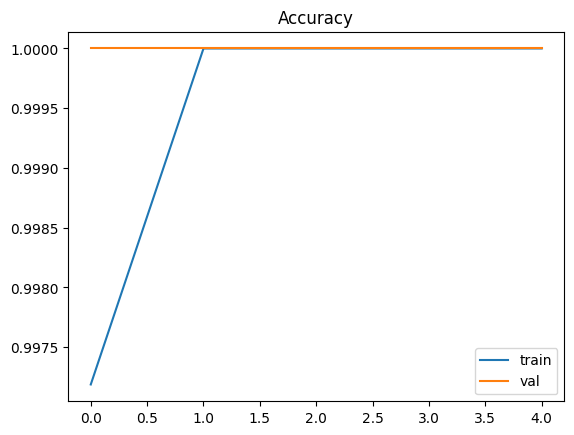

In [20]:
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.legend()
plt.title("Accuracy")
plt.show()

In [21]:
import os
os.makedirs("models", exist_ok=True)

model.save("models/mask_detector.keras")

In [22]:
from tensorflow.keras.models import load_model
model = load_model("models/mask_detector.keras")

In [23]:
def detect_mask(image_path):
    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    )

    image = cv2.imread(image_path)
    output = image.copy()

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    for (x, y, w, h) in faces:
        face = image[y:y+h, x:x+w]
        face = cv2.resize(face, (224, 224))
        face = face / 255.0
        face = np.reshape(face, (1, 224, 224, 3))

        pred = model.predict(face)[0][0]

        label = "Mask" if pred < 0.5 else "No Mask"
        color = (0, 255, 0) if label == "Mask" else (0, 0, 255)

        cv2.rectangle(output, (x, y), (x+w, y+h), color, 2)
        cv2.putText(output, label, (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

    # Convert BGR → RGB for display
    output = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)
    
    plt.imshow(output)
    plt.axis("off")
    plt.show()

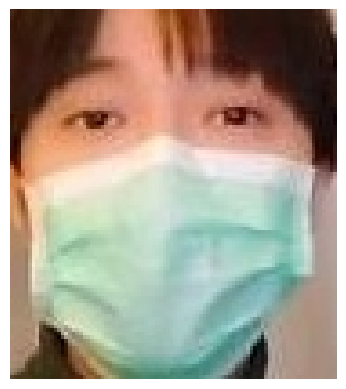

In [25]:
detect_mask("Computer vision dataset/data/test_images/test.jpg")